# Baseline ABSA - Classical ML (TF-IDF + Linear Models)


In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, Normalizer
from sklearn.feature_selection import SelectKBest, chi2, SelectFromModel
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
ASPECT_COLS = [
    'as_content',
    'as_physical',
    'as_price',
    'as_packaging',
    'as_delivery',
    'as_service',
]
SENTIMENT_COL = 'sentiment_llm'
TEXT_COL = 'content'
ID_COL = 'review_id'
ABSENT_LABEL = 3
USE_VN_SEGMENTATION = True


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for c in candidates:
        if (c / 'data' / 'processed' / 'train_clean.json').exists() and (c / 'notebooks').exists():
            return c
    return cwd


ROOT = find_project_root()
TRAIN_PATH = ROOT / 'data' / 'processed' / 'train_clean.json'
VAL_PATH = ROOT / 'data' / 'processed' / 'val_clean.json'
TEST_PATH = ROOT / 'data' / 'processed' / 'test_clean.json'
OUT_DIR = ROOT / 'experiments' / 'baseline_logreg'
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)


In [2]:
def _build_vn_segmenter():
    if not USE_VN_SEGMENTATION:
        return None, 'disabled'

    try:
        from underthesea import word_tokenize as uts_word_tokenize

        def segment_fn(text: str) -> str:
            return uts_word_tokenize(text, format='text')

        return segment_fn, 'underthesea'
    except Exception:
        pass

    return None, 'fallback_raw_text'


def _validate_schema(df: pd.DataFrame, name: str) -> None:
    required = {ID_COL, TEXT_COL, SENTIMENT_COL, *ASPECT_COLS}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f'{name} missing columns: {missing}')


def _prepare_frame(df: pd.DataFrame, name: str, segmenter=None) -> pd.DataFrame:
    _validate_schema(df, name)
    out = df.copy()
    out[TEXT_COL] = out[TEXT_COL].fillna('').astype(str)

    if segmenter is not None:
        out[TEXT_COL] = out[TEXT_COL].map(lambda x: segmenter(x) if x else x)

    out[SENTIMENT_COL] = pd.to_numeric(out[SENTIMENT_COL], errors='coerce')
    out = out.dropna(subset=[SENTIMENT_COL])
    out[SENTIMENT_COL] = out[SENTIMENT_COL].astype(int)
    out = out[out[SENTIMENT_COL].isin([0, 1, 2])].reset_index(drop=True)

    for col in ASPECT_COLS:
        out[col] = pd.to_numeric(out[col], errors='coerce')
        out[col] = out[col].where(out[col].isin([0, 1, 2]), np.nan)

    return out


def load_splits() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    segmenter, segmenter_name = _build_vn_segmenter()

    train = _prepare_frame(pd.read_json(TRAIN_PATH), 'train', segmenter=segmenter)
    val = _prepare_frame(pd.read_json(VAL_PATH), 'val', segmenter=segmenter)
    test = _prepare_frame(pd.read_json(TEST_PATH), 'test', segmenter=segmenter)

    print(f'Vietnamese segmenter: {segmenter_name}')
    return train, val, test


def to_aspect_matrix(frame: pd.DataFrame) -> np.ndarray:
    return frame[ASPECT_COLS].fillna(ABSENT_LABEL).astype(int).to_numpy()


def macro_f1(y_true: np.ndarray, y_pred: np.ndarray, labels: list[int]) -> float:
    _, _, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        average='macro',
        zero_division=0,
    )
    return float(f1)


In [3]:
def compute_metrics_absa(
    true_sent: np.ndarray,
    pred_sent: np.ndarray,
    true_aspects: np.ndarray,
    pred_aspects: np.ndarray,
    aspect_cols: list[str],
) -> dict:
    f1_sent = macro_f1(true_sent, pred_sent, labels=[0, 1, 2])

    present_mask = true_aspects.flatten() != ABSENT_LABEL
    f1_asp_present = 0.0
    f1_asp_neutral_present = 0.0
    acc_asp_present = 0.0
    if present_mask.any():
        true_present = true_aspects.flatten()[present_mask]
        pred_present = pred_aspects.flatten()[present_mask]
        f1_asp_present = macro_f1(
            true_present,
            pred_present,
            labels=[0, 1, 2],
        )
        _, _, f1_asp_neutral_present, _ = precision_recall_fscore_support(
            true_present,
            pred_present,
            labels=[1],
            average='macro',
            zero_division=0,
        )
        acc_asp_present = accuracy_score(true_present, pred_present)

    f1_asp_all = macro_f1(
        true_aspects.flatten(),
        pred_aspects.flatten(),
        labels=[0, 1, 2, 3],
    )

    asp_f1s = {}
    asp_neutral_f1s = {}
    for i, col in enumerate(aspect_cols):
        mask_i = true_aspects[:, i] != ABSENT_LABEL
        if mask_i.any():
            true_i = true_aspects[:, i][mask_i]
            pred_i = pred_aspects[:, i][mask_i]
            f1_i = macro_f1(
                true_i,
                pred_i,
                labels=[0, 1, 2],
            )
            _, _, f1_i_neutral, _ = precision_recall_fscore_support(
                true_i,
                pred_i,
                labels=[1],
                average='macro',
                zero_division=0,
            )
        else:
            f1_i = 0.0
            f1_i_neutral = 0.0
        asp_f1s[f'f1_{col}'] = round(f1_i, 4)
        asp_neutral_f1s[f'f1_neutral_{col}'] = round(float(f1_i_neutral), 4)

    f1_combined = 0.5 * f1_sent + 0.5 * f1_asp_present

    acc_sent = accuracy_score(true_sent, pred_sent)
    acc_asp_all = accuracy_score(true_aspects.flatten(), pred_aspects.flatten())

    metrics = {
        'f1_sentiment': round(f1_sent, 4),
        'f1_aspect_all': round(f1_asp_all, 4),
        'f1_aspect_present': round(f1_asp_present, 4),
        'f1_aspect_neutral_present': round(float(f1_asp_neutral_present), 4),
        'f1_combined': round(f1_combined, 4),
        'acc_sentiment': round(float(acc_sent), 4),
        'acc_aspect_present': round(float(acc_asp_present), 4),
        'acc_aspect_all': round(float(acc_asp_all), 4),
        **asp_f1s,
        **asp_neutral_f1s,
    }
    return metrics


In [4]:
def _build_meta_features(text_series) -> np.ndarray:
    s = pd.Series(text_series).fillna('').astype(str)

    char_count = s.str.len().to_numpy(dtype=np.float32)
    word_count = s.str.split().str.len().to_numpy(dtype=np.float32)
    exclaim_count = s.str.count('!').to_numpy(dtype=np.float32)
    question_count = s.str.count(r'\?').to_numpy(dtype=np.float32)
    uppercase_ratio = s.map(lambda t: sum(ch.isupper() for ch in t) / max(len(t), 1)).to_numpy(dtype=np.float32)

    return np.vstack([
        char_count,
        word_count,
        exclaim_count,
        question_count,
        uppercase_ratio,
    ]).T


def _build_text_features(cfg: dict) -> FeatureUnion:
    min_df = cfg['min_df']
    max_df = cfg['max_df']
    char_max_df = cfg.get('char_max_df', max_df)

    return FeatureUnion([
        ('word_tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=min_df,
            max_df=max_df,
            lowercase=False,
            sublinear_tf=True,
            strip_accents=None,
        )),
        ('char_tfidf', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            min_df=min_df,
            max_df=char_max_df,
            lowercase=False,
            sublinear_tf=True,
            strip_accents=None,
        )),
        ('meta_features', Pipeline([
            ('build', FunctionTransformer(_build_meta_features, validate=False)),
            ('scale', StandardScaler(with_mean=False)),
        ])),
    ])


class SafeSelectKBest(BaseEstimator, TransformerMixin):
    def __init__(self, score_func=chi2, k=20000):
        self.score_func = score_func
        self.k = k

    def fit(self, X, y=None):
        if self.k == 'all':
            k_effective = 'all'
        else:
            k_effective = min(int(self.k), int(X.shape[1]))
        self.selector_ = SelectKBest(score_func=self.score_func, k=k_effective)
        self.selector_.fit(X, y)
        self.k_effective_ = k_effective
        return self

    def transform(self, X):
        return self.selector_.transform(X)

    def get_support(self, indices=False):
        return self.selector_.get_support(indices=indices)


def _build_dim_reducer(cfg: dict):
    method = cfg.get('dim_reduce', 'none')

    if method == 'none':
        return 'passthrough'

    if method == 'chi2':
        return SafeSelectKBest(score_func=chi2, k=cfg.get('chi2_k', 20000))

    if method == 'svd':
        return Pipeline([
            ('svd', TruncatedSVD(n_components=cfg.get('svd_components', 512), random_state=RANDOM_STATE)),
            ('norm', Normalizer(copy=False)),
        ])

    if method == 'chi2_svd':
        return Pipeline([
            ('chi2', SafeSelectKBest(score_func=chi2, k=cfg.get('chi2_k', 20000))),
            ('svd', TruncatedSVD(n_components=cfg.get('svd_components', 512), random_state=RANDOM_STATE)),
            ('norm', Normalizer(copy=False)),
        ])

    if method == 'l1_select':
        l1_estimator = LogisticRegression(
            penalty='l1',
            solver='saga',
            C=cfg.get('l1_select_C', 0.5),
            max_iter=3000,
            random_state=RANDOM_STATE,
        )
        return SelectFromModel(l1_estimator, threshold=cfg.get('l1_threshold', 'median'))

    raise ValueError(f"Unsupported dim_reduce method: {method}")


def _make_classifier(cfg: dict, class_weight='balanced'):
    model_name = cfg.get('model', 'logreg_lbfgs')

    if model_name == 'dummy_majority':
        return DummyClassifier(strategy='most_frequent')

    if model_name == 'linear_svc':
        return LinearSVC(
            C=cfg['C'],
            class_weight=class_weight,
            random_state=RANDOM_STATE,
        )

    if model_name == 'sgd_elasticnet':
        return SGDClassifier(
            loss='log_loss',
            penalty='elasticnet',
            alpha=cfg.get('alpha', 1e-5),
            l1_ratio=cfg.get('l1_ratio', 0.15),
            class_weight=class_weight,
            max_iter=4000,
            tol=1e-3,
            random_state=RANDOM_STATE,
        )

    solver = 'saga' if model_name == 'logreg_saga' else 'lbfgs'
    return LogisticRegression(
        C=cfg['C'],
        class_weight=class_weight,
        max_iter=5000,
        solver=solver,
        random_state=RANDOM_STATE,
    )


def make_pipeline(*, cfg: dict, class_weight='balanced') -> Pipeline:
    return Pipeline([
        ('features', _build_text_features(cfg)),
        ('dim_reduce', _build_dim_reducer(cfg)),
        ('clf', _make_classifier(cfg, class_weight=class_weight)),
    ])


def _fit_dummy_model(dummy_model: DummyClassifier, y_train: np.ndarray) -> DummyClassifier:
    # Dummy ignores feature values; fit on one synthetic column for sklearn API consistency.
    x_stub = np.zeros((len(y_train), 1), dtype=np.float32)
    dummy_model.fit(x_stub, y_train)
    return dummy_model


def _predict_positive_score(model, x_split: pd.Series) -> np.ndarray:
    if isinstance(model, DummyClassifier):
        x_stub = np.zeros((len(x_split), 1), dtype=np.float32)
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(x_stub)
            classes = model.classes_
            if 1 in classes:
                idx = int(np.where(classes == 1)[0][0])
                return probs[:, idx]
            return np.zeros(len(x_split), dtype=float)
        return model.predict(x_stub).astype(float)

    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(x_split)
        classes = model.classes_
        if 1 in classes:
            idx = int(np.where(classes == 1)[0][0])
            return probs[:, idx]
        return np.zeros(len(x_split), dtype=float)

    if hasattr(model, 'decision_function'):
        scores = model.decision_function(x_split)
        scores = np.asarray(scores, dtype=float)
        if scores.ndim == 2:
            if hasattr(model, 'classes_') and 1 in model.classes_:
                idx = int(np.where(model.classes_ == 1)[0][0])
                scores = scores[:, idx]
            else:
                scores = scores[:, -1]
        scores = np.clip(scores, -30, 30)
        return 1.0 / (1.0 + np.exp(-scores))

    return model.predict(x_split).astype(float)


def _predict_sentiment_labels(x_split: pd.Series, sent_model, sent_fallback: int) -> np.ndarray:
    if sent_model is None or isinstance(sent_model, DummyClassifier):
        return np.full(shape=len(x_split), fill_value=sent_fallback, dtype=int)
    return sent_model.predict(x_split).astype(int)


def fit_presence_model(
    x_train: pd.Series,
    y_presence: np.ndarray,
    cfg: dict,
):
    unique_presence = np.unique(y_presence)
    majority_label = int(pd.Series(y_presence).mode().iloc[0])

    if unique_presence.shape[0] < 2:
        dummy = DummyClassifier(strategy='constant', constant=majority_label)
        return _fit_dummy_model(dummy, y_presence)

    model = make_pipeline(cfg=cfg, class_weight='balanced')
    model.fit(x_train, y_presence)
    return model


def fit_aspect_sent_model(x_train: pd.Series, y_aspect: np.ndarray, cfg: dict):
    present_mask = y_aspect != ABSENT_LABEL
    if present_mask.sum() == 0:
        return None, 0

    y_present = y_aspect[present_mask]
    unique_present = np.unique(y_present)
    majority_label = int(pd.Series(y_present).mode().iloc[0])

    if unique_present.shape[0] < 2:
        dummy = DummyClassifier(strategy='constant', constant=majority_label)
        dummy = _fit_dummy_model(dummy, y_present)
        return dummy, majority_label

    classes = np.unique(y_present)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_present)
    class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

    # Optional neutral boost to improve recall/F1 of class 1 on present-only aspect sentiment.
    neutral_boost = float(cfg.get('neutral_class_boost', 1.0))
    neutral_cap_ratio = float(cfg.get('neutral_weight_cap_ratio', 2.5))
    if 1 in class_weight and neutral_boost != 1.0:
        non_neutral = [w for cls, w in class_weight.items() if cls != 1]
        non_neutral_max = max(non_neutral) if non_neutral else class_weight[1]
        boosted_weight = class_weight[1] * neutral_boost
        capped_weight = non_neutral_max * neutral_cap_ratio
        class_weight[1] = float(min(boosted_weight, capped_weight))

    model = make_pipeline(cfg=cfg, class_weight=class_weight)
    model.fit(x_train[present_mask], y_present)
    return model, majority_label


def tune_presence_threshold(
    x_val: pd.Series,
    y_val_aspect: np.ndarray,
    presence_model,
    sent_model,
    sent_fallback: int,
    neutral_weight: float = 0.0,
) -> float:
    true_present_mask = y_val_aspect != ABSENT_LABEL
    if not true_present_mask.any():
        return 0.5

    sent_pred = _predict_sentiment_labels(x_val, sent_model, sent_fallback)
    presence_score = _predict_positive_score(presence_model, x_val)

    thr_grid = np.linspace(0.05, 0.90, 35)
    best_thr = 0.5
    best_obj = -1.0

    for thr in thr_grid:
        pred_presence = (presence_score >= thr).astype(int)
        pred_aspect = np.where(pred_presence == 0, ABSENT_LABEL, sent_pred)

        f1_all = macro_f1(
            y_val_aspect,
            pred_aspect,
            labels=[0, 1, 2, ABSENT_LABEL],
        )

        f1_present_macro = macro_f1(
            y_val_aspect[true_present_mask],
            pred_aspect[true_present_mask],
            labels=[0, 1, 2],
        )

        _, _, f1_neutral_present, _ = precision_recall_fscore_support(
            y_val_aspect[true_present_mask],
            pred_aspect[true_present_mask],
            labels=[1],
            average='macro',
            zero_division=0,
        )

        # Objective biases threshold search toward neutral quality while retaining overall stability.
        neutral_obj = (1.0 - neutral_weight) * f1_present_macro + neutral_weight * float(f1_neutral_present)
        objective = 0.8 * neutral_obj + 0.2 * f1_all

        if objective > best_obj:
            best_obj = float(objective)
            best_thr = float(thr)

    return best_thr


def predict_aspect(
    x_split: pd.Series,
    presence_model,
    presence_threshold: float,
    sent_model,
    sent_fallback: int,
) -> np.ndarray:
    presence_score = _predict_positive_score(presence_model, x_split)
    pred_presence = (presence_score >= presence_threshold).astype(int)

    pred_sent = _predict_sentiment_labels(x_split, sent_model, sent_fallback)
    pred_aspect = np.where(pred_presence == 0, ABSENT_LABEL, pred_sent)
    return pred_aspect.astype(int)


In [5]:
train_df, val_df, test_df = load_splits()

print(f'train rows: {len(train_df):,}')
print(f'val rows:   {len(val_df):,}')
print(f'test rows:  {len(test_df):,}')

print('\nSentiment distribution (train):')
print(train_df[SENTIMENT_COL].value_counts().sort_index())

coverage = train_df[ASPECT_COLS].notna().mean().mul(100).round(2)
print('\nAspect coverage % (train):')
print(coverage)

Vietnamese segmenter: underthesea
train rows: 9,360
val rows:   2,009
test rows:  2,005

Sentiment distribution (train):
sentiment_llm
0    4900
1    1514
2    2946
Name: count, dtype: int64

Aspect coverage % (train):
as_content      31.67
as_physical     39.12
as_price         9.19
as_packaging    17.99
as_delivery     25.52
as_service       3.23
dtype: float64


## EDA visual - khai thac pattern an

Cac bieu do duoi day giup nhin nhanh mat can bang nhan, phu aspect, do dai review, tu khoa noi bat va xu huong dong xuat hien aspect de dinh huong feature/regularization cho baseline Logistic.



In [6]:
# 1) Chuan bi bien phuc vu EDA
sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
eda_df = train_df.copy()
eda_df['sentiment_name'] = eda_df[SENTIMENT_COL].map(sentiment_map).fillna(eda_df[SENTIMENT_COL].astype(str))
eda_df['char_len'] = eda_df[TEXT_COL].str.len()
eda_df['word_len'] = eda_df[TEXT_COL].str.split().str.len()

aspect_presence = eda_df[ASPECT_COLS].notna().astype(int)
presence_rate = aspect_presence.mean().sort_values(ascending=False).mul(100)

print('EDA frame shape:', eda_df.shape)
print('Avg word length:', round(eda_df['word_len'].mean(), 2))



EDA frame shape: (9360, 12)
Avg word length: 26.36


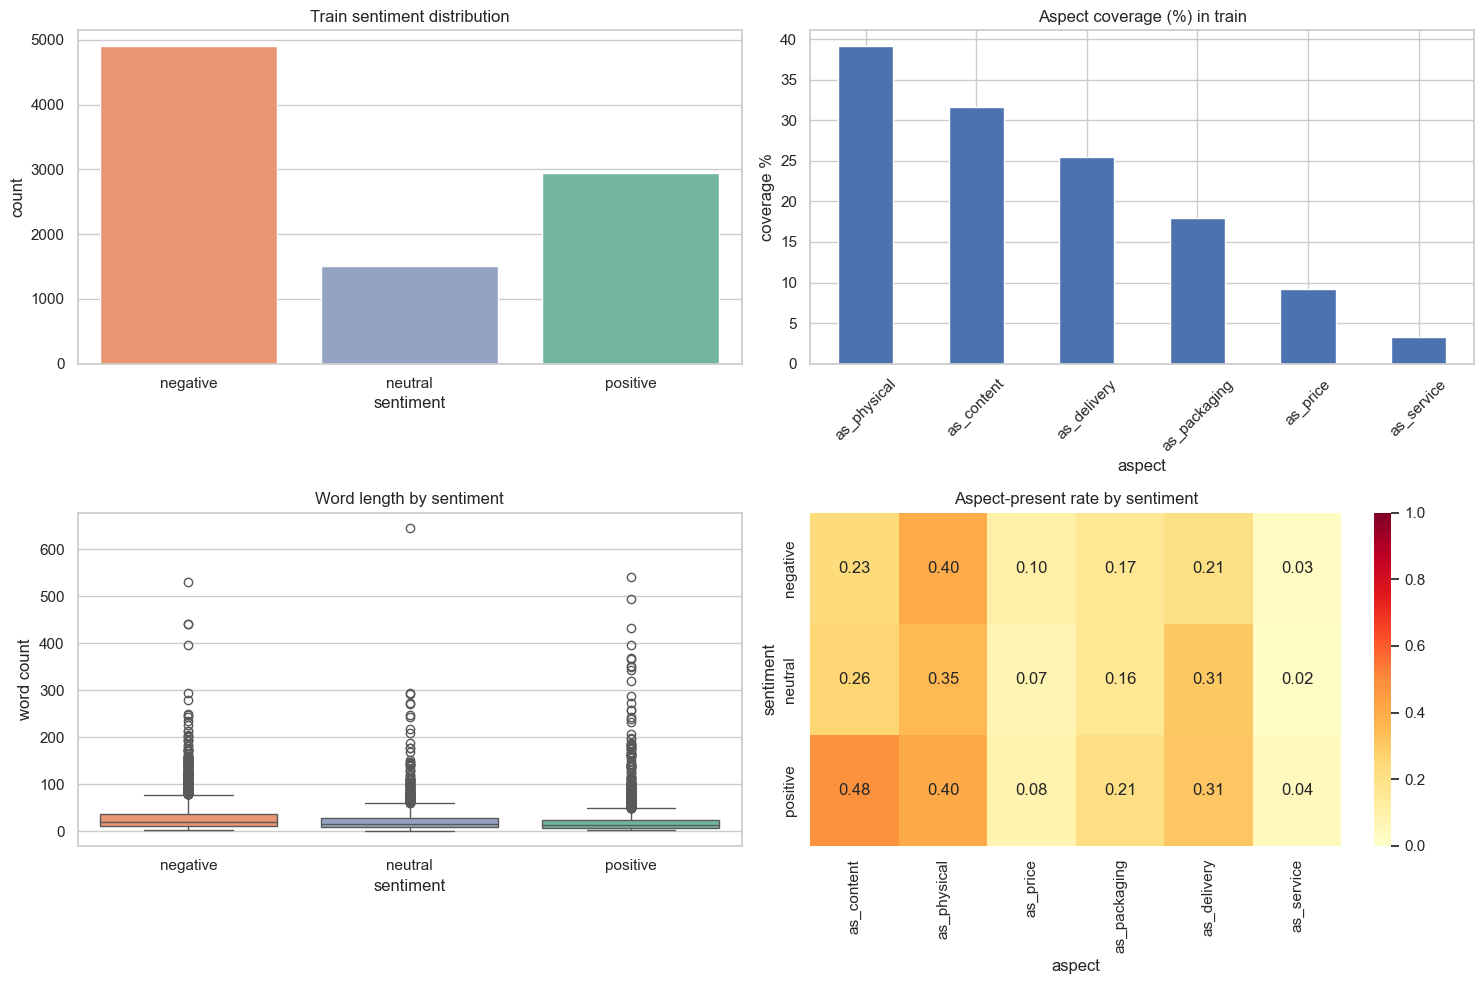

In [7]:
# 2) Visual tong quan: sentiment, coverage, do dai, aspect-by-sentiment
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(
    data=eda_df,
    x='sentiment_name',
    hue='sentiment_name',
    order=['negative', 'neutral', 'positive'],
    ax=axes[0, 0],
    palette='Set2',
    legend=False,
)
axes[0, 0].set_title('Train sentiment distribution')
axes[0, 0].set_xlabel('sentiment')
axes[0, 0].set_ylabel('count')

presence_rate.plot(kind='bar', ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title('Aspect coverage (%) in train')
axes[0, 1].set_xlabel('aspect')
axes[0, 1].set_ylabel('coverage %')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(
    data=eda_df,
    x='sentiment_name',
    y='word_len',
    hue='sentiment_name',
    order=['negative', 'neutral', 'positive'],
    ax=axes[1, 0],
    palette='Set2',
    legend=False,
)
axes[1, 0].set_title('Word length by sentiment')
axes[1, 0].set_xlabel('sentiment')
axes[1, 0].set_ylabel('word count')

aspect_by_sent = (
    eda_df.assign(**{col: eda_df[col].notna().astype(int) for col in ASPECT_COLS})
    .groupby('sentiment_name')[ASPECT_COLS]
    .mean()
    .reindex(['negative', 'neutral', 'positive'])
)
sns.heatmap(aspect_by_sent, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1, 1], vmin=0, vmax=1)
axes[1, 1].set_title('Aspect-present rate by sentiment')
axes[1, 1].set_xlabel('aspect')
axes[1, 1].set_ylabel('sentiment')

plt.tight_layout()
plt.show()



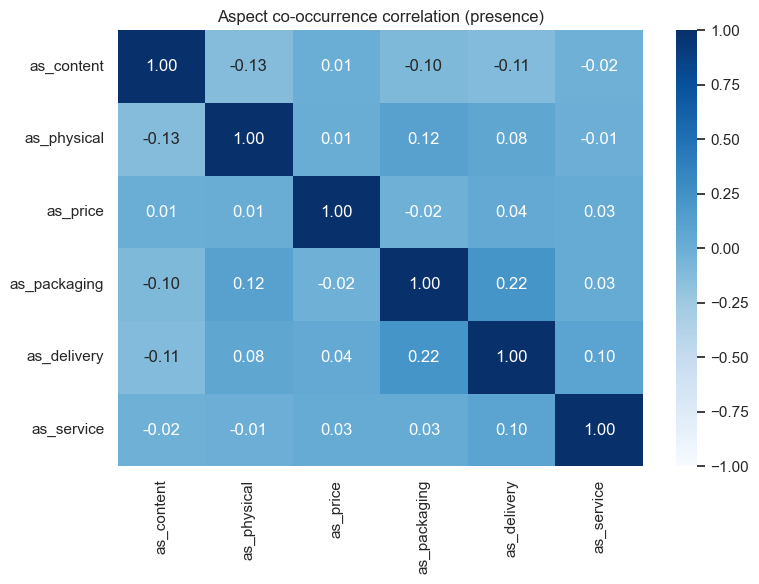

In [8]:
# 3) Heatmap dong xuat hien aspect
co_occurrence = aspect_presence.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1)
plt.title('Aspect co-occurrence correlation (presence)')
plt.tight_layout()
plt.show()



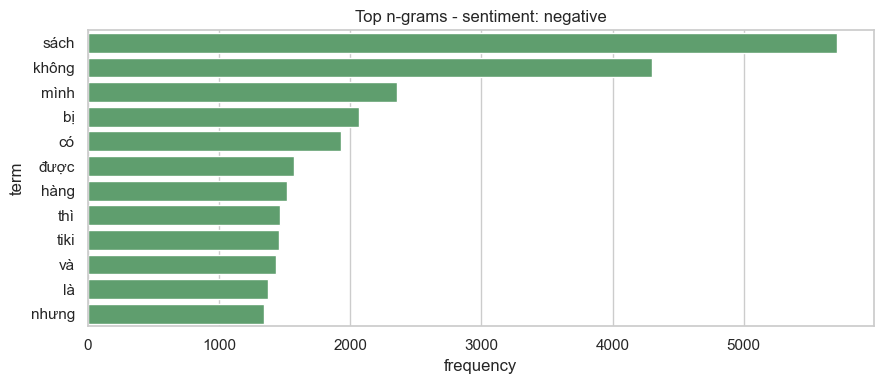

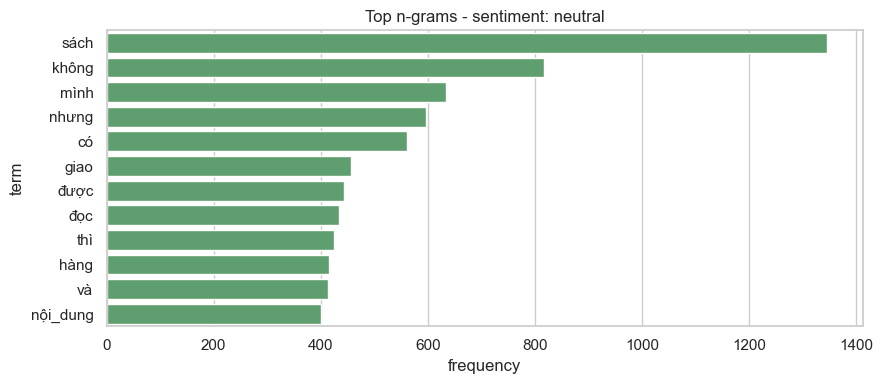

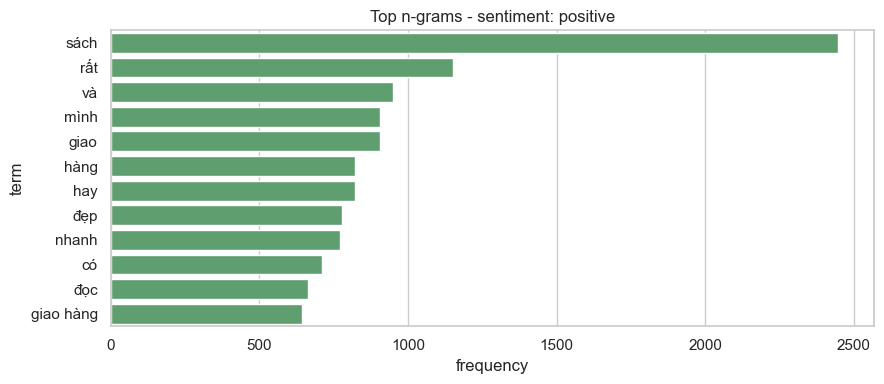

In [9]:
# 4) Top token/ngram theo sentiment
for sent_id, sent_name in sentiment_map.items():
    subset = eda_df.loc[eda_df[SENTIMENT_COL] == sent_id, TEXT_COL]
    if subset.empty:
        continue

    vec = CountVectorizer(ngram_range=(1, 2), min_df=3, max_features=3000)
    X = vec.fit_transform(subset)
    token_freq = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())

    top_k = 12
    top_idx = np.argsort(token_freq)[-top_k:][::-1]
    top_terms = pd.DataFrame({'term': vocab[top_idx], 'freq': token_freq[top_idx]})

    plt.figure(figsize=(9, 4))
    sns.barplot(data=top_terms, x='freq', y='term', color='#55A868')
    plt.title(f'Top n-grams - sentiment: {sent_name}')
    plt.xlabel('frequency')
    plt.ylabel('term')
    plt.tight_layout()
    plt.show()


In [10]:
BEST_MODEL_CFG = {
    'name': 'best_lr_saga_c8_min4',
    'model': 'logreg_saga',
    'C': 8.0,
    'min_df': 4,
    'max_df': 0.95,
    'char_max_df': 0.95,
    'neutral_class_boost': 1.35,
    'neutral_weight_cap_ratio': 2.5,
    'presence_threshold_neutral_weight': 0.35,
}

# Anchor config for comparison across future modeling upgrades.
ANCHOR_DIM_NAME = 'chi2_20k'
ANCHOR_EXPERIMENT_NAME = f"{BEST_MODEL_CFG['name']}__{ANCHOR_DIM_NAME}"

DIM_REDUCE_ZOO = [
    {'dim_name': 'none', 'dim_reduce': 'none'},
    {'dim_name': 'chi2_20k', 'dim_reduce': 'chi2', 'chi2_k': 20000},
    {'dim_name': 'svd_512', 'dim_reduce': 'svd', 'svd_components': 512},
    {'dim_name': 'chi2_20k_svd_512', 'dim_reduce': 'chi2_svd', 'chi2_k': 20000, 'svd_components': 512},
    {'dim_name': 'l1_select_median', 'dim_reduce': 'l1_select', 'l1_select_C': 0.5, 'l1_threshold': 'median'},
]


def _merge_cfg(model_cfg: dict, dim_cfg: dict) -> dict:
    cfg = {**model_cfg, **dim_cfg}
    cfg['name'] = f"{model_cfg['name']}__{dim_cfg['dim_name']}"
    return cfg


cfg_grid = [_merge_cfg(BEST_MODEL_CFG, d) for d in DIM_REDUCE_ZOO]

plan_df = pd.DataFrame([
    {
        'name': c['name'],
        'model': c['model'],
        'dim_name': c.get('dim_name', 'none'),
        'dim_reduce': c.get('dim_reduce', 'none'),
        'chi2_k': c.get('chi2_k'),
        'svd_components': c.get('svd_components'),
        'neutral_class_boost': c.get('neutral_class_boost'),
        'presence_threshold_neutral_weight': c.get('presence_threshold_neutral_weight'),
        'is_anchor': c['name'] == ANCHOR_EXPERIMENT_NAME,
    }
    for c in cfg_grid
])
print('Experiment mode: dim_reduction_focus')
print('Total configs:', len(cfg_grid))
print('Anchor config:', ANCHOR_EXPERIMENT_NAME)
plan_df.head(20)

X_train = train_df[TEXT_COL]
X_val = val_df[TEXT_COL]
X_test = test_df[TEXT_COL]

y_train_sent = train_df[SENTIMENT_COL].to_numpy()
y_val_sent = val_df[SENTIMENT_COL].to_numpy()
y_test_sent = test_df[SENTIMENT_COL].to_numpy()

y_train_asp = to_aspect_matrix(train_df)
y_val_asp = to_aspect_matrix(val_df)
y_test_asp = to_aspect_matrix(test_df)


Experiment mode: dim_reduction_focus
Total configs: 5
Anchor config: best_lr_saga_c8_min4__chi2_20k


In [11]:
experiments = []

for cfg in cfg_grid:
    print(f"Running {cfg['name']} | model={cfg['model']} | dim={cfg.get('dim_reduce', 'none')} ...")
    t_start = time.perf_counter()

    sentiment_model = make_pipeline(cfg=cfg, class_weight='balanced')
    sentiment_model.fit(X_train, y_train_sent)

    pred_val_sent = sentiment_model.predict(X_val).astype(int)

    aspect_models = {}
    pred_val_asp = np.full_like(y_val_asp, fill_value=ABSENT_LABEL)

    for i, col in enumerate(ASPECT_COLS):
        y_train_col = y_train_asp[:, i]
        y_val_col = y_val_asp[:, i]

        y_presence_train = (y_train_col != ABSENT_LABEL).astype(int)

        presence_model = fit_presence_model(
            x_train=X_train,
            y_presence=y_presence_train,
            cfg=cfg,
        )

        sent_model, sent_fallback = fit_aspect_sent_model(X_train, y_train_col, cfg)

        presence_threshold = tune_presence_threshold(
            x_val=X_val,
            y_val_aspect=y_val_col,
            presence_model=presence_model,
            sent_model=sent_model,
            sent_fallback=sent_fallback,
            neutral_weight=cfg.get('presence_threshold_neutral_weight', 0.0),
        )

        pred_val_col = predict_aspect(
            x_split=X_val,
            presence_model=presence_model,
            presence_threshold=presence_threshold,
            sent_model=sent_model,
            sent_fallback=sent_fallback,
        )

        pred_val_asp[:, i] = pred_val_col

        aspect_models[col] = {
            'presence_model': presence_model,
            'presence_threshold': presence_threshold,
            'sent_model': sent_model,
            'sent_fallback': sent_fallback,
        }

    val_metrics = compute_metrics_absa(
        true_sent=y_val_sent,
        pred_sent=pred_val_sent,
        true_aspects=y_val_asp,
        pred_aspects=pred_val_asp,
        aspect_cols=ASPECT_COLS,
    )
    fit_time_sec = round(time.perf_counter() - t_start, 2)

    experiments.append({
        'cfg': cfg,
        'sentiment_model': sentiment_model,
        'aspect_models': aspect_models,
        'pred_val_sent': pred_val_sent,
        'pred_val_asp': pred_val_asp,
        'val_metrics': val_metrics,
        'fit_time_sec': fit_time_sec,
    })

summary_rows = []
for exp in experiments:
    row = {
        'experiment': exp['cfg']['name'],
        'is_anchor': exp['cfg']['name'] == ANCHOR_EXPERIMENT_NAME,
        'model': exp['cfg']['model'],
        'C': exp['cfg']['C'],
        'min_df': exp['cfg']['min_df'],
        'max_df': exp['cfg']['max_df'],
        'char_max_df': exp['cfg']['char_max_df'],
        'dim_name': exp['cfg'].get('dim_name', 'none'),
        'dim_reduce': exp['cfg'].get('dim_reduce', 'none'),
        'chi2_k': exp['cfg'].get('chi2_k', np.nan),
        'svd_components': exp['cfg'].get('svd_components', np.nan),
        'l1_select_C': exp['cfg'].get('l1_select_C', np.nan),
        'l1_threshold': exp['cfg'].get('l1_threshold', ''),
        'fit_time_sec': exp.get('fit_time_sec', np.nan),
        'val_f1_combined': exp['val_metrics']['f1_combined'],
        'val_f1_sentiment': exp['val_metrics']['f1_sentiment'],
        'val_f1_aspect_present': exp['val_metrics']['f1_aspect_present'],
        'val_f1_aspect_neutral_present': exp['val_metrics']['f1_aspect_neutral_present'],
        'val_f1_aspect_all': exp['val_metrics']['f1_aspect_all'],
        'val_acc_sentiment': exp['val_metrics']['acc_sentiment'],
        'val_acc_aspect_present': exp['val_metrics']['acc_aspect_present'],
        'val_acc_aspect_all': exp['val_metrics']['acc_aspect_all'],
    }
    for col in ASPECT_COLS:
        row[f'val_f1_{col}'] = exp['val_metrics'][f'f1_{col}']
        row[f'val_f1_neutral_{col}'] = exp['val_metrics'][f'f1_neutral_{col}']
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('val_f1_combined', ascending=False).reset_index(drop=True)
summary_df


Running best_lr_saga_c8_min4__none | model=logreg_saga | dim=none ...
Running best_lr_saga_c8_min4__chi2_20k | model=logreg_saga | dim=chi2 ...
Running best_lr_saga_c8_min4__svd_512 | model=logreg_saga | dim=svd ...


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Running best_lr_saga_c8_min4__chi2_20k_svd_512 | model=logreg_saga | dim=chi2_svd ...


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Running best_lr_saga_c8_min4__l1_select_median | model=logreg_saga | dim=l1_select ...


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penal

,experiment,is_anchor,model,C,min_df,max_df,char_max_df,dim_name,dim_reduce,chi2_k,svd_components,l1_select_C,l1_threshold,fit_time_sec,val_f1_combined,val_f1_sentiment,val_f1_aspect_present,val_f1_aspect_neutral_present,val_f1_aspect_all,val_acc_sentiment,val_acc_aspect_present,val_acc_aspect_all,val_f1_as_content,val_f1_neutral_as_content,val_f1_as_physical,val_f1_neutral_as_physical,val_f1_as_price,val_f1_neutral_as_price,val_f1_as_packaging,val_f1_neutral_as_packaging,val_f1_as_delivery,val_f1_neutral_as_delivery,val_f1_as_service,val_f1_neutral_as_service
0,best_lr_saga_c8_min4__none,False,logreg_saga,8.0,4,0.95,0.95,none,none,NaN,NaN,NaN,,874.15,0.7644,0.7693,0.7595,0.5924,0.6969,0.8233,0.7940,0.8656,0.6855,0.3276,0.6867,0.3978,0.7889,0.8612,0.5572,0.0,0.8037,0.7097,0.5421,0.5600
1,best_lr_saga_c8_min4__l1_select_median,False,logreg_saga,8.0,4,0.95,0.95,l1_select_median,l1_select,NaN,NaN,0.5,median,2317.61,0.7644,0.7693,0.7595,0.5924,0.6969,0.8233,0.7940,0.8656,0.6855,0.3276,0.6867,0.3978,0.7889,0.8612,0.5572,0.0,0.8037,0.7097,0.5421,0.5600
2,best_lr_saga_c8_min4__chi2_20k,True,logreg_saga,8.0,4,0.95,0.95,chi2_20k,chi2,20000.0,NaN,NaN,,613.30,0.7623,0.7666,0.7581,0.5967,0.7045,0.8218,0.7862,0.8728,0.6772,0.3304,0.6860,0.4000,0.7907,0.8667,0.5596,0.0,0.8039,0.7097,0.5426,0.5833
3,best_lr_saga_c8_min4__chi2_20k_svd_512,False,logreg_saga,8.0,4,0.95,0.95,chi2_20k_svd_512,chi2_svd,20000.0,512.0,NaN,,825.90,0.7514,0.7592,0.7437,0.5848,0.5886,0.8084,0.7735,0.7592,0.6793,0.3636,0.7188,0.4977,0.7619,0.8517,0.5406,0.0,0.7437,0.6471,0.5930,0.4375
4,best_lr_saga_c8_min4__svd_512,False,logreg_saga,8.0,4,0.95,0.95,svd_512,svd,NaN,512.0,NaN,,980.32,0.7512,0.7560,0.7465,0.5869,0.5894,0.8034,0.7808,0.7586,0.6902,0.3750,0.7266,0.5135,0.7601,0.8462,0.5367,0.0,0.7443,0.6391,0.5859,0.4375


In [12]:
compare_cols = [
    'experiment', 'is_anchor', 'model', 'dim_name', 'dim_reduce',
    'val_f1_combined', 'val_f1_sentiment', 'val_f1_aspect_present', 'val_f1_aspect_neutral_present', 'val_f1_aspect_all',
    'fit_time_sec',
]
comparison_df = summary_df[compare_cols].copy()
comparison_df.insert(0, 'rank', np.arange(1, len(comparison_df) + 1))
for col in ['val_f1_combined', 'val_f1_sentiment', 'val_f1_aspect_present', 'val_f1_aspect_neutral_present', 'val_f1_aspect_all']:
    comparison_df[col] = comparison_df[col].round(4)
comparison_df['fit_time_sec'] = comparison_df['fit_time_sec'].round(2)

print('Experiment comparison (sorted by val_f1_combined):')
print(comparison_df.to_string(index=False))

anchor_row = summary_df.loc[summary_df['experiment'] == ANCHOR_EXPERIMENT_NAME]
if not anchor_row.empty:
    anchor_rank = int(anchor_row.index[0]) + 1
    print()
    print(f"Anchor config ({ANCHOR_EXPERIMENT_NAME}) is at rank: {anchor_rank}")
    print(anchor_row[[
        'val_f1_combined',
        'val_f1_sentiment',
        'val_f1_aspect_present',
        'val_f1_aspect_neutral_present',
        'fit_time_sec',
    ]].round(4).to_string(index=False))

best_name = summary_df.iloc[0]['experiment']
best_exp = next(e for e in experiments if e['cfg']['name'] == best_name)

pred_test_sent = best_exp['sentiment_model'].predict(X_test).astype(int)
pred_test_asp = np.full_like(y_test_asp, fill_value=ABSENT_LABEL)

for i, col in enumerate(ASPECT_COLS):
    payload = best_exp['aspect_models'][col]
    pred_test_col = predict_aspect(
        x_split=X_test,
        presence_model=payload['presence_model'],
        presence_threshold=payload['presence_threshold'],
        sent_model=payload['sent_model'],
        sent_fallback=payload['sent_fallback'],
    )
    pred_test_asp[:, i] = pred_test_col

test_metrics = compute_metrics_absa(
    true_sent=y_test_sent,
    pred_sent=pred_test_sent,
    true_aspects=y_test_asp,
    pred_aspects=pred_test_asp,
    aspect_cols=ASPECT_COLS,
)

best_exp['pred_test_sent'] = pred_test_sent
best_exp['pred_test_asp'] = pred_test_asp
best_exp['test_metrics'] = test_metrics

print('Best config by val_f1_combined:', best_name)
print()
print('Val metrics:')
print(best_exp['val_metrics'])
print()
print('Test metrics (evaluated once on selected best config):')
print(best_exp['test_metrics'])

print()
print('Presence threshold per aspect (selected from val):')
for col in ASPECT_COLS:
    print(f"- {col}: {best_exp['aspect_models'][col]['presence_threshold']:.2f}")


Experiment comparison (sorted by val_f1_combined):
 rank                             experiment  is_anchor       model         dim_name dim_reduce  val_f1_combined  val_f1_sentiment  val_f1_aspect_present  val_f1_aspect_neutral_present  val_f1_aspect_all  fit_time_sec
    1             best_lr_saga_c8_min4__none      False logreg_saga             none       none           0.7644            0.7693                 0.7595                         0.5924             0.6969        874.15
    2 best_lr_saga_c8_min4__l1_select_median      False logreg_saga l1_select_median  l1_select           0.7644            0.7693                 0.7595                         0.5924             0.6969       2317.61
    3         best_lr_saga_c8_min4__chi2_20k       True logreg_saga         chi2_20k       chi2           0.7623            0.7666                 0.7581                         0.5967             0.7045        613.30
    4 best_lr_saga_c8_min4__chi2_20k_svd_512      False logreg_saga chi2_20k_

In [13]:
# Classification reports (TEST)
print('=== OVERALL SENTIMENT (TEST SET) ===')
print(classification_report(
    y_test_sent,
    best_exp['pred_test_sent'],
    labels=[0, 1, 2],
    target_names=['Negative', 'Neutral', 'Positive'],
    zero_division=0,
))

print('=== 6 ASPECTS: present only (TEST SET) ===')
present_mask = y_test_asp.flatten() != ABSENT_LABEL
print(classification_report(
    y_test_asp.flatten()[present_mask],
    best_exp['pred_test_asp'].flatten()[present_mask],
    labels=[0, 1, 2],
    target_names=['Negative', 'Neutral', 'Positive'],
    zero_division=0,
))

print('=== Per-aspect F1 (TEST, present only) ===')
asp_f1_table = pd.Series(
    {col: best_exp['test_metrics'][f'f1_{col}'] for col in ASPECT_COLS},
    name='f1_test_present',
).to_frame().sort_values('f1_test_present', ascending=False)
print(asp_f1_table)

print('=== Per-aspect Neutral F1 (TEST, present only) ===')
asp_neutral_f1_table = pd.Series(
    {col: best_exp['test_metrics'][f'f1_neutral_{col}'] for col in ASPECT_COLS},
    name='f1_test_neutral_present',
).to_frame().sort_values('f1_test_neutral_present', ascending=False)
print(asp_neutral_f1_table)


=== OVERALL SENTIMENT (TEST SET) ===
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      1048
     Neutral       0.57      0.62      0.59       324
    Positive       0.86      0.85      0.85       633

    accuracy                           0.83      2005
   macro avg       0.78      0.79      0.78      2005
weighted avg       0.84      0.83      0.84      2005

=== 6 ASPECTS: present only (TEST SET) ===
              precision    recall  f1-score   support

    Negative       0.82      0.79      0.80       805
     Neutral       0.67      0.61      0.64       410
    Positive       0.91      0.86      0.89      1291

   micro avg       0.84      0.80      0.82      2506
   macro avg       0.80      0.76      0.78      2506
weighted avg       0.84      0.80      0.82      2506

=== Per-aspect F1 (TEST, present only) ===
              f1_test_present
as_delivery            0.7860
as_content             0.7240
as_physical            0.

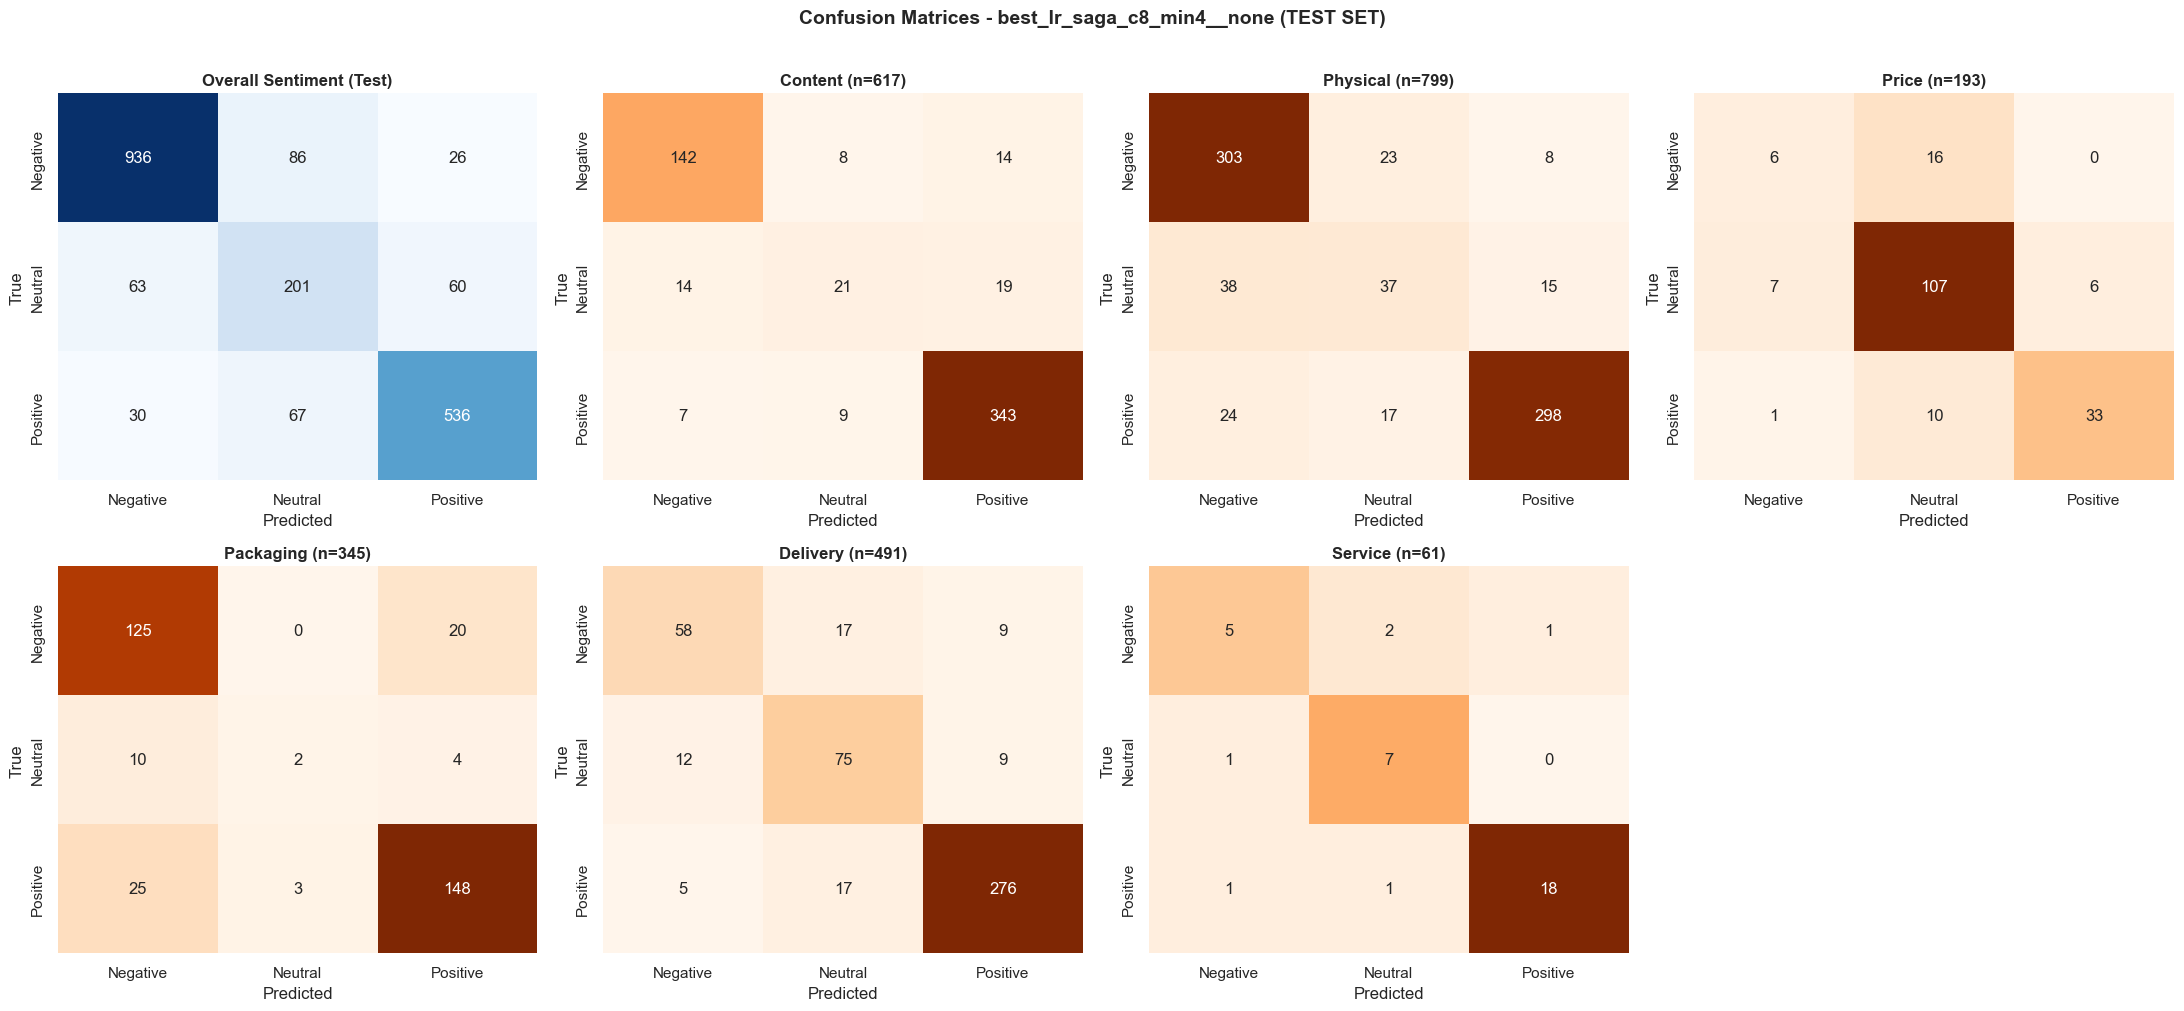

In [14]:
# Confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
names = ['Negative', 'Neutral', 'Positive']
asp_display = ['Content', 'Physical', 'Price', 'Packaging', 'Delivery', 'Service']

cm_sent = confusion_matrix(y_test_sent, best_exp['pred_test_sent'], labels=[0, 1, 2])
sns.heatmap(
    cm_sent,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=names,
    yticklabels=names,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title('Overall Sentiment (Test)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

for j, (col, disp) in enumerate(zip(ASPECT_COLS, asp_display)):
    ax = axes[j + 1]
    idx = ASPECT_COLS.index(col)
    true_col = y_test_asp[:, idx]
    pred_col = best_exp['pred_test_asp'][:, idx]
    mask = true_col != ABSENT_LABEL
    if not mask.any():
        ax.set_visible(False)
        continue

    cm = confusion_matrix(true_col[mask], pred_col[mask], labels=[0, 1, 2])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Oranges',
        xticklabels=names,
        yticklabels=names,
        ax=ax,
        cbar=False,
    )
    ax.set_title(f'{disp} (n={mask.sum()})', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

if len(axes) > 7:
    axes[7].set_visible(False)

plt.suptitle(f'Confusion Matrices - {best_name} (TEST SET)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Save artifacts
summary_path = OUT_DIR / 'metrics_summary.csv'
summary_df.to_csv(summary_path, index=False)

with open(OUT_DIR / 'metrics_val.json', 'w', encoding='utf-8') as f:
    json.dump(best_exp['val_metrics'], f, ensure_ascii=False, indent=2)

with open(OUT_DIR / 'metrics_test.json', 'w', encoding='utf-8') as f:
    json.dump(best_exp['test_metrics'], f, ensure_ascii=False, indent=2)

# Predictions (test)
pred_df = test_df[[ID_COL]].copy()
pred_df['true_sentiment'] = y_test_sent
pred_df['pred_sentiment'] = best_exp['pred_test_sent']

for i, col in enumerate(ASPECT_COLS):
    pred_df[f'true_{col}'] = y_test_asp[:, i]
    pred_df[f'pred_{col}'] = best_exp['pred_test_asp'][:, i]

pred_path = OUT_DIR / 'predictions_test.csv'
pred_df.to_csv(pred_path, index=False)

neutral_f1_path = OUT_DIR / 'aspect_neutral_f1_test.csv'
neutral_f1_df = pd.DataFrame({
    'aspect': ASPECT_COLS,
    'f1_neutral_present_test': [best_exp['test_metrics'][f'f1_neutral_{col}'] for col in ASPECT_COLS],
}).sort_values('f1_neutral_present_test', ascending=False)
neutral_f1_df.to_csv(neutral_f1_path, index=False)

# Models
joblib.dump(best_exp['sentiment_model'], OUT_DIR / 'model_sentiment.joblib')

for col, payload in best_exp['aspect_models'].items():
    joblib.dump(payload['presence_model'], OUT_DIR / f'model_{col}_presence.joblib')
    if payload['sent_model'] is not None:
        joblib.dump(payload['sent_model'], OUT_DIR / f'model_{col}_sentiment.joblib')

print('Saved:')
print('-', summary_path)
print('-', OUT_DIR / 'metrics_val.json')
print('-', OUT_DIR / 'metrics_test.json')
print('-', pred_path)
print('-', neutral_f1_path)
print('-', OUT_DIR / 'model_sentiment.joblib')


Saved:
- D:\DataPreprocessing\DoAn2\experiments\baseline_logreg\metrics_summary.csv
- D:\DataPreprocessing\DoAn2\experiments\baseline_logreg\metrics_val.json
- D:\DataPreprocessing\DoAn2\experiments\baseline_logreg\metrics_test.json
- D:\DataPreprocessing\DoAn2\experiments\baseline_logreg\predictions_test.csv
- D:\DataPreprocessing\DoAn2\experiments\baseline_logreg\aspect_neutral_f1_test.csv
- D:\DataPreprocessing\DoAn2\experiments\baseline_logreg\model_sentiment.joblib


## Notes
- Baseline nay la classical ML + threshold tuning; muc tieu la moc tham chieu ro rang truoc khi fine-tune mo hinh ngon ngu.
- Da bo sung segmentation tieng Viet (underthesea neu co), word+char TF-IDF va handcrafted features.
- Da chot che do train `dim_reduction_focus`: co dinh model tot nhat (`logreg_saga`, C=8, min_df=4, max_df=0.95) va chi quet cac phuong an giam chieu.
- Threshold calibration cho presence duoc toi uu theo downstream macro-F1 sentiment-tren-aspect-present (khong chi binary F1 presence).
- Limitations: segmentation phu thuoc package co san; chua dung lexicon/domain features; chua co cross-validation nhieu fold.


In [16]:
# === INFERENCE VÀ SO SÁNH VỚI NHÃN THẬT (TẬP TEST) ===
def predict_review_logreg(text: str, best_exp: dict, segmenter) -> dict:
    import pandas as pd
    import numpy as np
    x_split = pd.Series([segmenter(str(text)) if segmenter else str(text)])
    pred_sent = _predict_sentiment_labels(x_split, best_exp['sentiment_model'], sent_fallback=1)[0]
    
    pred_asps = {}
    for col in ASPECT_COLS:
        payload = best_exp['aspect_models'][col]
        pred_col = predict_aspect(
            x_split=x_split,
            presence_model=payload['presence_model'],
            presence_threshold=payload['presence_threshold'],
            sent_model=payload['sent_model'],
            sent_fallback=payload['sent_fallback'],
        )[0]
        pred_asps[col] = pred_col
        
    sentiment_map = {0: 'Tiêu cực', 1: 'Trung lập', 2: 'Tích cực', 3: 'Không nhắc đến'}
    
    result = {
        'text': text,
        'sentiment_llm': sentiment_map.get(pred_sent, 'Unknown')
    }
    for col in ASPECT_COLS:
        result[col] = sentiment_map.get(pred_asps[col], 'Unknown')
        
    return result
    
# Khởi tạo segmenter
segmenter, _ = _build_vn_segmenter()

sentiment_map = {0: 'Tiêu cực', 1: 'Trung lập', 2: 'Tích cực', 3: 'Không nhắc đến'}

# Lấy 5 mẫu ngẫu nhiên từ tập test
sample_df = test_df.sample(5, random_state=42)

print('Dự đoán trên tập test:\n')
for idx, row in sample_df.iterrows():
    text = row[TEXT_COL].replace('_', ' ')
    # Remove underline from underthesea tokenization if present in text col, just formatting
    res = predict_review_logreg(text, best_exp, segmenter)
    print(f"Review: {res['text']}")
    print(f"  - Sentiment chung : Dự đoán: {res['sentiment_llm']:15s} | Thực tế: {sentiment_map.get(row[SENTIMENT_COL], 'Unknown')}")
    
    for col in ASPECT_COLS:
        true_label = sentiment_map.get(row[col], 'Không nhắc đến')
        if res[col] != 'Không nhắc đến' or true_label != 'Không nhắc đến':
            print(f"  - {col:15s} : Dự đoán: {res[col]:15s} | Thực tế: {true_label}")
    print('-'*80)


Dự đoán trên tập test:

Review: hài lòng về sản phẩm nhưng không hài lòng về giao hàng , hơi trễ so với những lần khác mình mua
  - Sentiment chung : Dự đoán: Tiêu cực        | Thực tế: Trung lập
  - as_delivery     : Dự đoán: Tích cực        | Thực tế: Tích cực
--------------------------------------------------------------------------------
Review: sách rất là to nhìn dễ thương lắm để hôm nào tập tô thử giống các bạn . giao hàng nhanh hôm qua đặt hôm nay đã có
  - Sentiment chung : Dự đoán: Tích cực        | Thực tế: Tích cực
  - as_content      : Dự đoán: Tích cực        | Thực tế: Không nhắc đến
  - as_physical     : Dự đoán: Không nhắc đến  | Thực tế: Tích cực
  - as_delivery     : Dự đoán: Tích cực        | Thực tế: Tích cực
--------------------------------------------------------------------------------
Review: rất hay nhé giao hàng nhanh đáng mua nha
  - Sentiment chung : Dự đoán: Tích cực        | Thực tế: Tích cực
  - as_content      : Dự đoán: Tích cực        | Thực tế: Tích 